### py311_env - Python environment

In [57]:
!pip install -q deepeval

In [58]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [59]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams, Turn, TurnParams, ConversationalTestCase

import pandas as pd
from deepeval.dataset import Golden

from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate


In [60]:
convo_geval_focus = ConversationalGEval(name="Focus", criteria = "Does the response directly address the specific question or task?")
convo_geval_helpful = ConversationalGEval(name="Helpful", criteria = "Does the response meaningfully help the user?")
convo_geval_completeness = ConversationalGEval(name="Completeness", criteria = "Does the response fully address the question without major omissions?")
convo_geval_voice = ConversationalGEval(name="Voice", criteria = "Does the response use clear, active voice?")
convo_geval_engagement = ConversationalGEval(name="Engagement", criteria = "Does the response use appropriate and engaging language?")

convo_completeness = ConversationCompletenessMetric()

In [61]:
import pandas as pd
data = pd.read_csv("data_bank/medium.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What is the average total deposit balance by g...,Key Insights:\n\nThe calculated average minimu...
1,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,Which geographical region has the highest conc...,Great question but unfortunately no data point...
2,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What is the total deposit balance for the top ...,High-Impact Findings\n\nThe total deposit bala...
3,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,How many accounts in the last 6 months have de...,Key Insight:\nNo accounts in the last 6 months...
4,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What percentage of accounts with no recent act...,"Key Insights\n\nOut of 1,000 accounts with no ..."


In [62]:
turns = []
for idx, row in data_sel.iterrows():
    turn_user = Turn(role="user", retrieval_context=[f"user persona: {row['persona']}", f"KPI : {row['kpi']}"]  ,content=row["synthetic_questions"])   
    turn_assistant = Turn(role="assistant", content=row["tursio_response"])
    convo_test_case = ConversationalTestCase(turns=[turn_user, turn_assistant])

    turns.append(convo_test_case)

print (f"Added test cases for {len(turns)}")

Added test cases for 20


In [63]:
turns[0]

ConversationalTestCase(turns=[Turn(role='user', content='What is the average total deposit balance by geography for accounts opened in the last year?', retrieval_context=['user persona: Finance / Treasury Manager; Branch / Regional Manager', 'KPI : Total Deposit Balance by Geography; Concentration Risk']), Turn(role='assistant', content='Key Insights:\n\nThe calculated average minimum balance for accounts opened between 2024-12-18 and 2025-12-18 is 611.34.\nNo explicit geography grouping was applied in the query, so this average reflects the overall dataset for the specified account opening period.')], scenario=None, context=None, name=None, user_description=None, expected_outcome=None, chatbot_role=None, additional_metadata=None, comments=None, tags=None, mcp_servers=None, multimodal=False)

In [64]:
import time
import os
from deepeval.evaluate import AsyncConfig

import sys
from io import StringIO
import contextlib


# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 2  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(turns), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(convo_test_case.turns))}")
    
    test_batch = turns[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[convo_geval_focus
                        , convo_geval_completeness
                        , convo_geval_engagement
                        , convo_geval_helpful
                        , convo_geval_voice
                        , convo_completeness],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Focus [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Completeness [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Engagement [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Helpful [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Voice [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

...

✨ You're running DeepEval's latest Conversation Completeness Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

Evaluating test cases 18 to 2


⚠ WARNING: No hyperparameters logged.
» ]8;id=36169;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 31.94s | token cost: 0.023131999999999996 USD)
» Test Results (2 total tests):
   » Pass Rate: 100.0% | Passed: 2 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 20 test cases


In [65]:
all_results[0].metrics_data

[MetricData(name='Focus [Conversational GEval]', threshold=0.5, success=True, score=0.5496401396586561, reason="The assistant correctly identifies the average balance for accounts opened in the last year and clarifies that no geography grouping was applied, which is relevant and clear. However, the user's question specifically asked for the average by geography, and the assistant did not provide a breakdown or attempt to group by geography, resulting in a partial but incomplete fulfillment of the user's request.", strict_mode=False, evaluation_model='gpt-4.1', error=None, evaluation_cost=0.002824, verbose_logs='Criteria:\nDoes the response directly address the specific question or task? \n \nEvaluation Steps:\n[\n    "For each turn, identify the Role (user or assistant) and determine the expected action based on the Role.",\n    "Examine the Content of each assistant response to check if it directly addresses the specific question or task posed by the user in the previous turn.",\n    

In [66]:
import pandas as pd

data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'turns': test_result.turns,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
     
        # Assuming one metric per test case for simplicity based on previous output
        metric_data = m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,turns,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,conversational_test_case_0,None,None,None,[role='user' content='What is the average tota...,False,Focus [Conversational GEval],0.549640,0.5,True,The assistant correctly identifies the average...
1,conversational_test_case_0,None,None,None,[role='user' content='What is the average tota...,False,Completeness [Conversational GEval],0.556700,0.5,True,The assistant's response is appropriate for it...
2,conversational_test_case_0,None,None,None,[role='user' content='What is the average tota...,False,Engagement [Conversational GEval],0.698167,0.5,True,The assistant's response is informative and us...
3,conversational_test_case_0,None,None,None,[role='user' content='What is the average tota...,False,Helpful [Conversational GEval],0.611920,0.5,True,The assistant correctly identifies the average...
4,conversational_test_case_0,None,None,None,[role='user' content='What is the average tota...,False,Voice [Conversational GEval],0.796136,0.5,True,The user's question is clear and uses active v...


In [67]:
df_results.shape

(120, 11)

In [68]:
df_results.to_csv("deepeval_tursio_results_medium_convo.csv", index=False)

In [69]:
df_results.metric_name.unique()

array(['Focus [Conversational GEval]',
       'Completeness [Conversational GEval]',
       'Engagement [Conversational GEval]',
       'Helpful [Conversational GEval]', 'Voice [Conversational GEval]',
       'Conversation Completeness'], dtype=object)

In [70]:
df_results[df_results['metric_success'] == False].groupby(["metric_name"])["name"].count()

metric_name
Completeness [Conversational GEval]     4
Conversation Completeness              11
Engagement [Conversational GEval]       3
Focus [Conversational GEval]            4
Helpful [Conversational GEval]          4
Voice [Conversational GEval]            2
Name: name, dtype: int64

In [71]:
df_results[df_results['metric_success'] == False]["metric_reason"].values

array(["The score is 0.0 because the LLM response did not address the user's intention to provide the average total deposit balance by geography for accounts opened in the last year. Instead, it only gave an overall average without the required geographic breakdown, leaving the user's request completely unmet.",
       "The score is 0.0 because the LLM response did not address the user's intention at all; instead of identifying the geographical region with the highest concentration of high-balance accounts, it stated that no data was available and provided no relevant information.",
       "The assistant attempts to answer the user's question about total deposit balances for the top 5 customer segments by account number in each region, but only provides a single total for the top 5 records without addressing segmentation by customer segment or region. The response is partially relevant but omits key details requested by the user, failing to fully address the task.",
       "The assista

In [72]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(["The assistant correctly identifies the average balance for accounts opened in the last year and clarifies that no geography grouping was applied, which is relevant and clear. However, the user's question specifically asked for the average by geography, and the assistant did not provide a breakdown or attempt to group by geography, resulting in a partial but incomplete fulfillment of the user's request.",
       "The assistant's response is appropriate for its role and provides a clear calculation of the average deposit balance for accounts opened in the last year. However, the user's question specifically asks for the average by geography, which the assistant notes was not included in the query, but does not attempt to address or clarify further. The assistant should have either requested more information about the desired geographies or explained how to obtain the breakdown, resulting in a partial but incomplete answer.",
       "The assistant's response is informative and use

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

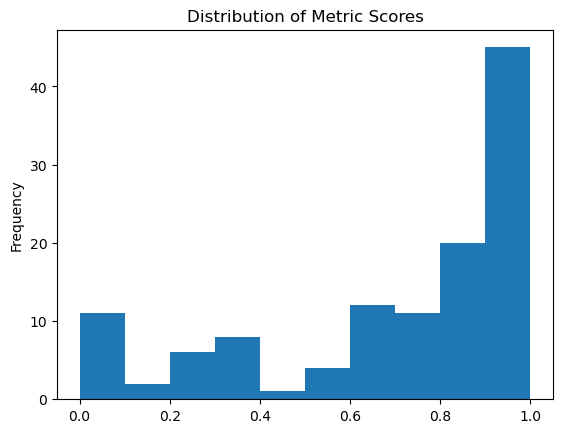

In [73]:
df_results.metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')